In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

In [2]:
df = pd.read_csv("neo_v2.csv")

In [3]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), object(2)
memory usage: 5.7+ MB


,id,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,9.083600e+04,90836.000000,90836.000000,90836.000000,9.083600e+04,90836.000000
mean,1.438288e+07,0.127432,0.284947,48066.918918,3.706655e+07,23.527103
std,2.087202e+07,0.298511,0.667491,25293.296961,2.235204e+07,2.894086
min,2.000433e+06,0.000609,0.001362,203.346433,6.745533e+03,9.230000
25%,3.448110e+06,0.019256,0.043057,28619.020645,1.721082e+07,21.340000
50%,3.748362e+06,0.048368,0.108153,44190.117890,3.784658e+07,23.700000
75%,3.884023e+06,0.143402,0.320656,62923.604633,5.654900e+07,25.700000
max,5.427591e+07,37.892650,84.730541,236990.128088,7.479865e+07,33.200000


In [4]:
df.isnull().sum()

,0
id,0
name,0
est_diameter_min,0
est_diameter_max,0
relative_velocity,0
miss_distance,0
orbiting_body,0
sentry_object,0
absolute_magnitude,0
hazardous,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df["hazardous"] = df["hazardous"].astype(int)

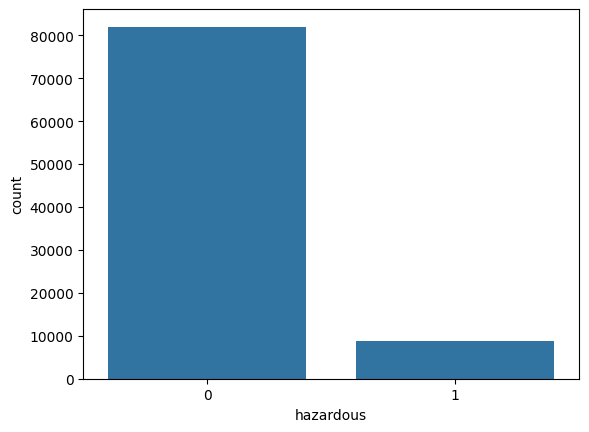

In [8]:
sns.countplot(x='hazardous', data=df)
plt.show()

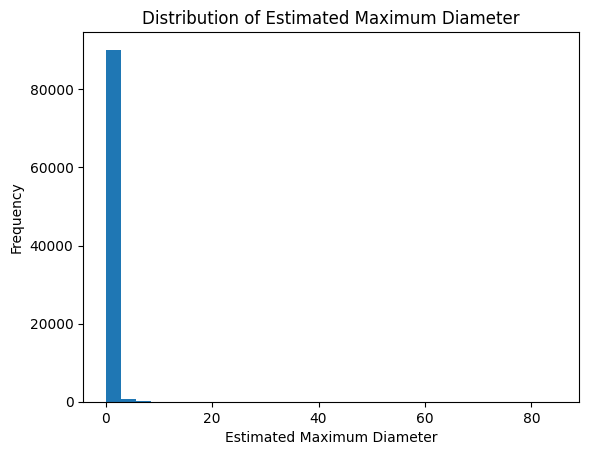

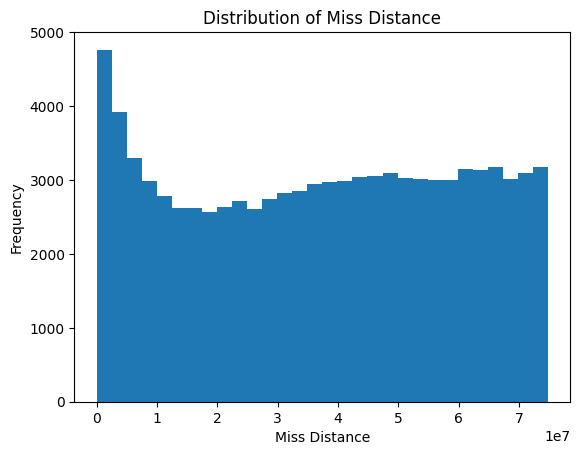

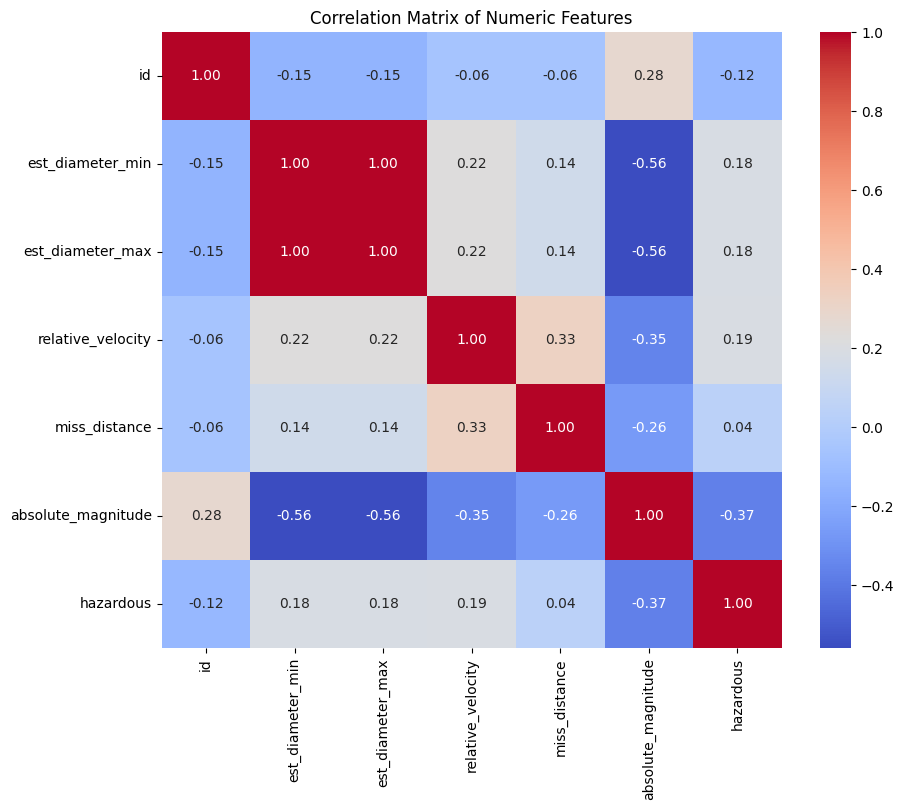

In [10]:
plt.hist(df["est_diameter_max"], bins=30)
plt.title("Distribution of Estimated Maximum Diameter")
plt.xlabel("Estimated Maximum Diameter")
plt.ylabel("Frequency")
plt.show()

plt.hist(df["miss_distance"], bins=30)
plt.title("Distribution of Miss Distance")
plt.xlabel("Miss Distance")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric Features")
plt.show()

In [11]:
le = LabelEncoder()

df["sentry_object"] = le.fit_transform(df["sentry_object"])

In [12]:
X = df.drop("hazardous", axis=1)

y = df["hazardous"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
      X,
          y,
              test_size=0.2,
                  random_state=42
                  )


In [15]:
scaler = StandardScaler()

X_train_scaled = X_train.drop(columns=['id', 'name', 'orbiting_body'], errors='ignore')
X_test_scaled = X_test.drop(columns=['id', 'name', 'orbiting_body'], errors='ignore')

X_train = scaler.fit_transform(X_train_scaled)
X_test = scaler.transform(X_test_scaled)

In [16]:
lr = LogisticRegression()

lr.fit(X_train,y_train)

pred1 = lr.predict(X_test)

In [17]:
print("Accuracy:",
      accuracy_score(y_test,pred1))
print("Precision:",
      precision_score(y_test,pred1))
print("Recall:",
      recall_score(y_test,pred1))
print("F1 Score:",
      f1_score(y_test,pred1))
print(confusion_matrix(y_test,pred1))

Accuracy: 0.9053280493174812
Precision: 0.5149501661129569
Recall: 0.0896471949103528
F1 Score: 0.15270935960591134
[[16293   146]
 [ 1574   155]]


In [18]:
dt = DecisionTreeClassifier()

dt.fit(X_train,y_train)

pred2 = dt.predict(X_test)

In [19]:
print("Accuracy:",
      accuracy_score(y_test, pred2))
print("Precision:",
      precision_score(y_test, pred2))
print("Recall:",
      recall_score(y_test, pred2))
print("F1 Score:",
      f1_score(y_test, pred2))
print(confusion_matrix(y_test, pred2))

Accuracy: 0.892338177014531
Precision: 0.4393372528059861
Recall: 0.47541931752458066
F1 Score: 0.45666666666666667
[[15390  1049]
 [  907   822]]


In [20]:
rf = RandomForestClassifier()

rf.fit(X_train,y_train)

pred3 = rf.predict(X_test)

In [21]:
print("Accuracy:",
      accuracy_score(y_test, pred3))
print("Precision:",
      precision_score(y_test, pred3))
print("Recall:",
      recall_score(y_test, pred3))
print("F1 Score:",
      f1_score(y_test, pred3))
print(confusion_matrix(y_test, pred3))

Accuracy: 0.9212901805372082
Precision: 0.6206618240516546
Recall: 0.44476576055523426
F1 Score: 0.5181940700808625
[[15969   470]
 [  960   769]]


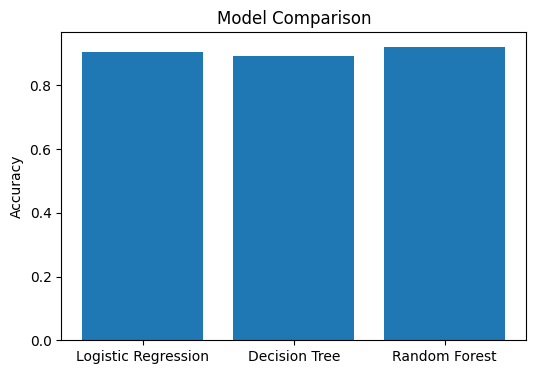

In [22]:
models = ['Logistic Regression',
          'Decision Tree',
          'Random Forest']

accuracy = [0.905,
            0.892,
            0.921]

plt.figure(figsize=(6,4))

plt.bar(models,accuracy)

plt.ylabel('Accuracy')

plt.title('Model Comparison')

plt.show()

Conclusion

Three supervised machine learning models were trained to predict whether an asteroid is hazardous.

After comparing Logistic Regression, Decision Tree and Random Forest, the Random Forest model achieved the highest accuracy of approximately 92%.

The results show that asteroid characteristics such as diameter, velocity and miss distance can be used to effectively predict hazard status.

This project demonstrates the usefulness of machine learning in space safety and asteroid risk assessment.